<a href="https://colab.research.google.com/github/anubhav123456/Deep-Learning/blob/main/7.%20Mathy%20Part/SN_on_mobile_cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
from mpl_toolkits import mplot3d
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, mean_squared_error
from tqdm import tqdm_notebook as tqdm
import seaborn as sns
sns.set_theme(style="darkgrid")
from google.colab import drive

# Loading Data

In [2]:
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
data = pd.read_csv('drive/My Drive/Datasets/data/mobile_cleaned.csv')

In [4]:
data.head()

,PhoneId,Pixel Density,Screen Size,Weight,RAM,Processor_frequency,Screen to Body Ratio (calculated),Height,Internal Memory,Capacity,...,os_name_Tizen,os_name_iOS,"SIM Slot(s)_Dual SIM, GSM+CDMA","SIM Slot(s)_Dual SIM, GSM+GSM","SIM Slot(s)_Dual SIM, GSM+GSM, Dual VoLTE","SIM Slot(s)_Single SIM, GSM",Sim1_2G,Sim1_3G,Sim1_4G,Rating
0,0,403,6.26,182,4,1.8,80.68,157.9,64,4000,...,0,0,0,0,1,0,0,0,1,4.5
1,1,271,6.20,168,3,1.8,80.85,156.2,32,4230,...,0,0,0,0,1,0,0,0,1,4.5
2,2,409,6.30,168,3,2.1,83.68,157.0,32,3500,...,0,0,0,0,1,0,0,0,1,4.4
3,4,411,6.00,169,4,2.2,74.78,159.8,64,3300,...,0,0,0,1,0,0,0,0,1,4.3
4,5,396,6.50,175,4,2.2,84.23,160.4,64,3750,...,0,0,0,0,1,0,0,0,1,4.4


In [5]:
data.shape

(341, 88)

In [6]:
print(type(data));

<class 'pandas.core.frame.DataFrame'>


* **`axis=0`** $\rightarrow$ Rows (Top to bottom / Downwards)
* **`axis=1`** $\rightarrow$ Columns (Left to right / Sideways)

In [7]:
X = data.drop('Rating', axis=1)
Y = data['Rating']

In [8]:
display(X.head());

,PhoneId,Pixel Density,Screen Size,Weight,RAM,Processor_frequency,Screen to Body Ratio (calculated),Height,Internal Memory,Capacity,...,os_name_Other,os_name_Tizen,os_name_iOS,"SIM Slot(s)_Dual SIM, GSM+CDMA","SIM Slot(s)_Dual SIM, GSM+GSM","SIM Slot(s)_Dual SIM, GSM+GSM, Dual VoLTE","SIM Slot(s)_Single SIM, GSM",Sim1_2G,Sim1_3G,Sim1_4G
0,0,403,6.26,182,4,1.8,80.68,157.9,64,4000,...,0,0,0,0,0,1,0,0,0,1
1,1,271,6.20,168,3,1.8,80.85,156.2,32,4230,...,0,0,0,0,0,1,0,0,0,1
2,2,409,6.30,168,3,2.1,83.68,157.0,32,3500,...,0,0,0,0,0,1,0,0,0,1
3,4,411,6.00,169,4,2.2,74.78,159.8,64,3300,...,0,0,0,0,1,0,0,0,0,1
4,5,396,6.50,175,4,2.2,84.23,160.4,64,3750,...,0,0,0,0,0,1,0,0,0,1


In [9]:
display(Y.head());

,Rating
0,4.5
1,4.5
2,4.4
3,4.3
4,4.4


# Data Frame to Numpy Arrays

In [10]:
X = X.values;
Y = Y.values;
print(type(X));
print(type(Y));
print(X.shape);
print(Y.shape);

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(341, 87)
(341,)


In [11]:
threshold = 4.2;
data['Class'] = data['Rating'] >= threshold;
data['Class'].head()

,Class
0,True
1,True
2,True
3,True
4,True


* Type Conversion from boolean to int

In [12]:
data['Class'] = data['Class'].astype(int);
data['Class'].head()

,Class
0,1
1,1
2,1
3,1
4,1


In [13]:
data['Class'].value_counts()

,count
Class,
0,182
1,159


## What does `normalize=True` mean?

When using `.value_counts(normalize=True)` in Pandas, it converts **raw counts into proportions (fractions)** instead of total counts.

---

### **How it works:**

* **Without `normalize=True` (Default):** Returns the exact count of each unique value in the column.
* **With `normalize=True`:** Returns the relative frequency of each unique value as a decimal between **0 and 1** (where the sum of all values equals **1.0**).

---

### **Example Output Breakdown:**

```text
1    0.58651
0    0.41349
```

In [14]:
print(data['Class'].value_counts(normalize=True));

Class
0    0.533724
1    0.466276
Name: proportion, dtype: float64


In [15]:
Y_true = data['Class'].values;
print(type(X));
print(type(Y_true));
print(X.shape)
print(Y_true.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(341, 87)
(341,)


# Standardisation

In [16]:
R = np.random.random([100, 1]);
print(R.shape)

(100, 1)


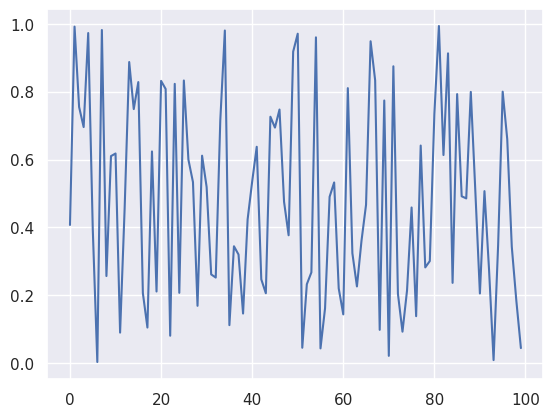

In [17]:
plt.plot(R);
plt.show();

In [18]:
print(np.mean(R));
print(np.std(R));

0.4807102807725223
0.2930066279975705


In [19]:
scaler = StandardScaler();
scaler.fit(R);

In [20]:
print(scaler.mean_);

[0.48071028]


In [21]:
# To get Standard Deviation
print(scaler.scale_)

[0.29300663]


In [22]:
RT = scaler.transform(R);
print(RT.shape);

(100, 1)


In [23]:
print(np.mean(RT));
print(np.std(RT));

8.659739592076221e-17
1.0


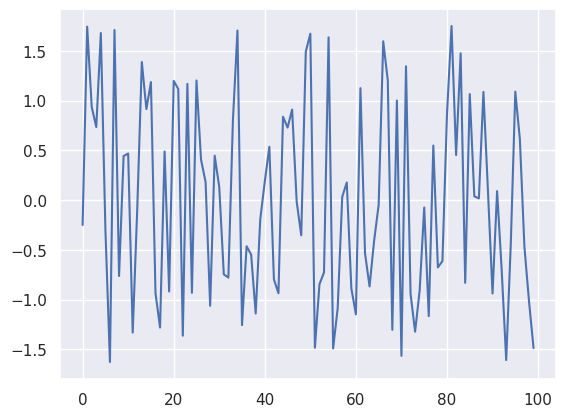

In [24]:
plt.plot(RT);
plt.show();

# Train Test Split

# What is `stratify` in `train_test_split`?

The `stratify` parameter ensures that the **class distribution (ratio) of the target variable remains identical** across both the Training set and Test set after splitting.

---

## **Why is it needed?**

Without `stratify`, `train_test_split` selects samples randomly. This creates a risk where one class might be overrepresented in the training data and completely missing in the test data (or vice versa).

`stratify` eliminates this randomness by preserving original class proportions.

---

## **Example Scenario**

Suppose you have a dataset of **100 rows** ($Y$):
* **80 rows** = Class 0 (80%)
* **20 rows** = Class 1 (20%)

You want an **80/20 Train-Test split**:

### **1. Without `stratify` (`stratify=None`)**
* Split is completely random.
* **Train Set:** 70 Class 0, 10 Class 1
* **Test Set:** 10 Class 0, 10 Class 1 *(Ratio gets distorted!)*

### **2. With `stratify=Y`**
* Scikit-Learn maintains the original 80:20 class ratio in both splits.
* **Train Set (80 rows):** 64 Class 0 (80%), 16 Class 1 (20%)
* **Test Set (20 rows):** 16 Class 0 (80%), 4 Class 1 (20%)

---

## **When to use `stratify`?**

1. **Classification Tasks:** Highly recommended for almost all classification problems.
2. **Imbalanced Datasets:** Crucial when dealing with rare target classes (e.g., Fraud Detection, Disease Diagnosis, Spam Detection) to prevent training/testing failures.

---

## **Syntax**

```python
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=0,
    stratify=Y  # Pass target column/labels here
)

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=0, stratify=Y_true);

In [26]:
print("1s (%):", np.mean(Y_true == 1) * 100)
print("0s (%):", np.mean(Y_true == 0) * 100)

1s (%): 46.62756598240469
0s (%): 53.3724340175953


In [27]:
scaler = StandardScaler();
X_scaled_train = scaler.fit_transform(X_train);
X_scaled_test = scaler.transform(X_test);

* 1D to 2D Conversion

In [28]:
arr = np.array([10, 20, 30, 40])
print(arr)
print(arr.shape)
new_arr = arr.reshape(-1, 1)
print(new_arr)
print(new_arr.shape)

[10 20 30 40]
(4,)
[[10]
 [20]
 [30]
 [40]]
(4, 1)


# Min Max Scaling

# Min-Max Scaling (Normalization)

**Min-Max Scaling** rescales numerical features to fit within a specific fixed range, usually between **0 and 1**.

---

## **Mathematical Formula**

To scale values to the standard $[0, 1]$ range:

$$X_{new} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

### **Custom Range Formula $[a, b]$**
To scale values to a custom range, such as $[-1, 1]$:

$$X_{new} = a + \frac{(X - X_{min})(b - a)}{X_{max} - X_{min}}$$

---

## **Variable Key**

* **$X$**: The original value in the column.
* **$X_{min}$**: Minimum value in that feature column.
* **$X_{max}$**: Maximum value in that feature column.
* **$X_{new}$**: Transformed value.
* **$a, b$**: Desired minimum and maximum boundaries (e.g., $a = 0$, $b = 1$).

---

## **Key Characteristics**

1. **Fixed Bounded Range:** Maps all data strictly into $[0, 1]$ (or $[a, b]$).
2. **Preserves Relationships:** Maintains original relative distance between data points.
3. **Sensitive to Outliers:** Extreme values can heavily compress non-outlier data points into a narrow range.

---

## **Scikit-Learn Implementation**

```python
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler (default range is feature_range=(0, 1))
scaler = MinMaxScaler()

# Fit and transform the dataset
X_scaled = scaler.fit_transform(X)
```

In [29]:
min_max_scaler = MinMaxScaler();
Y_scaled_train = min_max_scaler.fit_transform(Y_train.reshape(-1, 1));
Y_scaled_test = min_max_scaler.transform(Y_test.reshape(-1, 1));

In [30]:
print(np.min(Y_scaled_train));
print(np.max(Y_scaled_train));
print(np.min(Y_scaled_test));
print(np.max(Y_scaled_test));

0.0
1.0
0.11999999999999988
1.0


In [31]:
scaled_threshold = list(min_max_scaler.transform(np.array([threshold]).reshape(1, -1)))[0][0];
print(scaled_threshold);

0.6800000000000002


In [32]:
Y_binarised_train = (Y_scaled_train > scaled_threshold).astype("int").ravel()
Y_binarised_test = (Y_scaled_test > scaled_threshold).astype("int").ravel()

# Class for Sigmoid

In [33]:
class SigmoidNeuron:
    def __init__(self):
        self.w = None
        self.b = None

    """
    computes x1*w1 + x2*w2 . . . + b
    """
    def perceptron(self, x):
        return np.dot(x.reshape(1, -1), self.w.T) + self.b

    """
    computes 1 / (1 + e^-x)
    """
    def sigmoid(self, x):
        return 1.0/(1.0 + np.exp(-x))

    def grad_w(self, x, y):
        # compute the predicted value, 1 / (1 + e^perceptron(x))
        # perceptron(x) will give x1*w1+x2*w2 . . . +b
        y_pred = self.sigmoid(self.perceptron(x))
        return (y_pred - y) * y_pred * (1 - y_pred) * x

    def grad_b(self, x, y):
        # compute the predicted value, 1 / (1 + e^perceptron(x))
        # perceptron(x) will give x1*w1+x2*w2 . . . +b
        y_pred = self.sigmoid(self.perceptron(x))
        return (y_pred - y) * y_pred * (1 - y_pred) * 1.0

    def fit(self, X, Y, epochs=1, learning_rate=1, initialize=True, display_loss=False):

        # initialize w, b

        if initialize:
            self.w = np.random.randn(1, X.shape[1])
            self.b = 0

        if display_loss:
          loss = {}

        # run for epoch number of times
        for i in tqdm(range(epochs), total=epochs, unit='epochs'):
            dw = 0
            db = 0
            # calculate delta_w and delta_b
            for x, y in zip(X, Y):
                dw += self.grad_w(x, y)
                db += self.grad_b(x, y)

            self.w -= learning_rate * dw
            self.b -= learning_rate * db

            if display_loss:
              Y_pred = self.predict(X)
              loss[i] = mean_squared_error(Y, Y_pred.ravel())

        if display_loss:
          print(f"Initial Loss : {loss[0]:.6f}")
          print(f"Final Loss   : {loss[epochs-1]:.6f}")

          # Best (Minimum) Loss
          best_epoch = min(loss, key=loss.get)
          best_loss = loss[best_epoch]

          print(f"Best Loss    : {best_loss:.6f}")
          print(f"Best Epoch   : {best_epoch + 1}")

          plt.figure(figsize=(8,5))
          plt.plot(loss.keys(), loss.values(), linewidth=2)
          plt.scatter(best_epoch, best_loss, color='red', s=80, label=f'Best Loss = {best_loss:.6f}\nEpoch = {best_epoch + 1}')
          plt.xlabel("Epoch")
          plt.ylabel("Mean Squared Error")
          plt.title("Training Loss vs Epoch")
          plt.legend()
          plt.grid(True)
          plt.show()

    def predict(self, X):
      Y_pred = []
      for x in X:
        y_pred = self.sigmoid(self.perceptron(x))
        Y_pred.append(y_pred)

      return np.array(Y_pred);

    def binarize(self, Y_pred, threshold=0.5):
      return (Y_pred > threshold).astype(int).ravel()

    def accuracy(self, Y_pred, Y_true):
      return accuracy_score(Y_pred, Y_true);

In [34]:
sigmoid_model = SigmoidNeuron()

/tmp/ipykernel_56041/4098597323.py:42: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(epochs), total=epochs, unit='epochs'):


  0%|          | 0/10 [00:00<?, ?epochs/s]

Initial Loss : 0.211486
Final Loss   : 0.133628
Best Loss    : 0.132439
Best Epoch   : 8


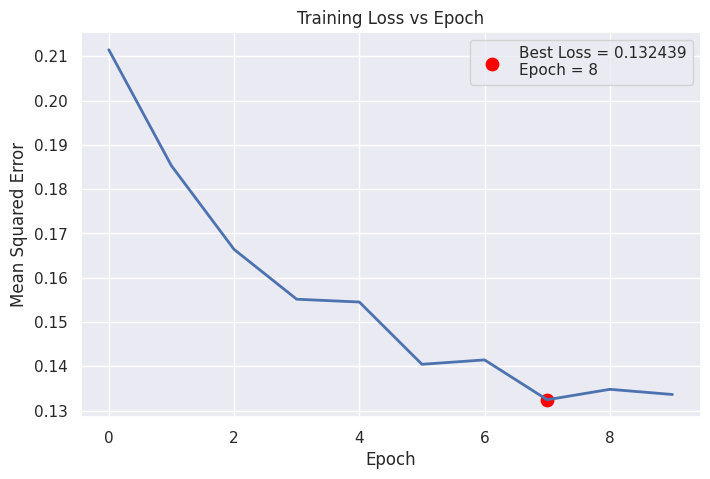

Epochs:  10
Learning Rate:  0.2
Train Accuracy:  0.5529411764705883
Test Accuracy:  0.5697674418604651




/tmp/ipykernel_56041/4098597323.py:42: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(epochs), total=epochs, unit='epochs'):


  0%|          | 0/1000 [00:00<?, ?epochs/s]

Initial Loss : 0.203886
Final Loss   : 0.106857
Best Loss    : 0.050749
Best Epoch   : 479


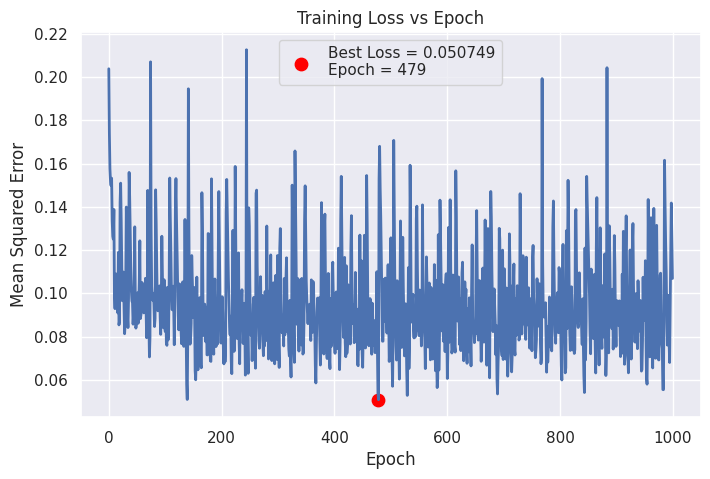

Epochs:  1000
Learning Rate:  0.2
Train Accuracy:  0.6509803921568628
Test Accuracy:  0.6627906976744186




/tmp/ipykernel_56041/4098597323.py:42: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(epochs), total=epochs, unit='epochs'):


  0%|          | 0/1000 [00:00<?, ?epochs/s]

Initial Loss : 0.266023
Final Loss   : 0.052254
Best Loss    : 0.052254
Best Epoch   : 1000


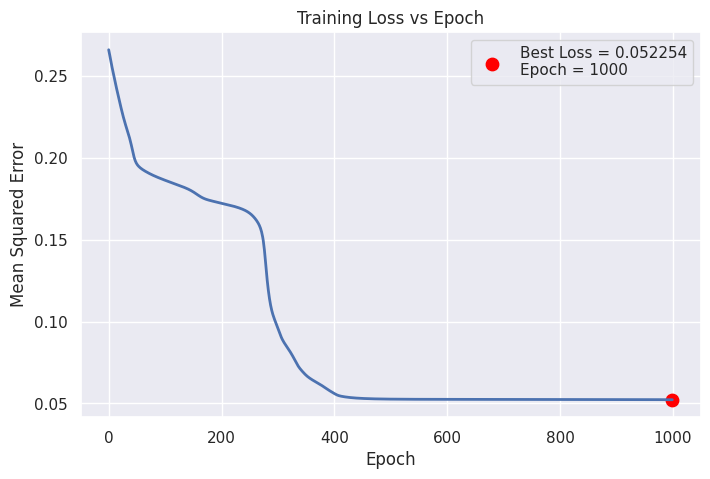

Epochs:  1000
Learning Rate:  0.01
Train Accuracy:  0.7529411764705882
Test Accuracy:  0.7325581395348837




/tmp/ipykernel_56041/4098597323.py:42: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(epochs), total=epochs, unit='epochs'):


  0%|          | 0/5000 [00:00<?, ?epochs/s]

Initial Loss : 0.211335
Final Loss   : 0.054533
Best Loss    : 0.054533
Best Epoch   : 5000


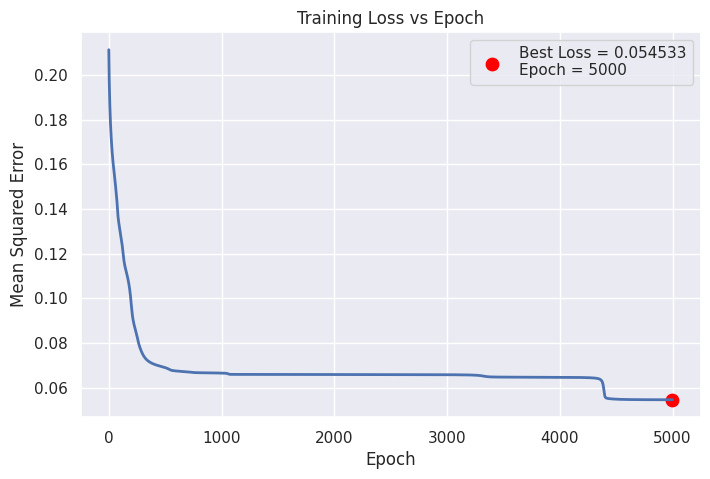

Epochs:  5000
Learning Rate:  0.01
Train Accuracy:  0.7764705882352941
Test Accuracy:  0.7325581395348837




/tmp/ipykernel_56041/4098597323.py:42: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(epochs), total=epochs, unit='epochs'):


  0%|          | 0/1000 [00:00<?, ?epochs/s]

Initial Loss : 0.272720
Final Loss   : 0.037689
Best Loss    : 0.037689
Best Epoch   : 1000


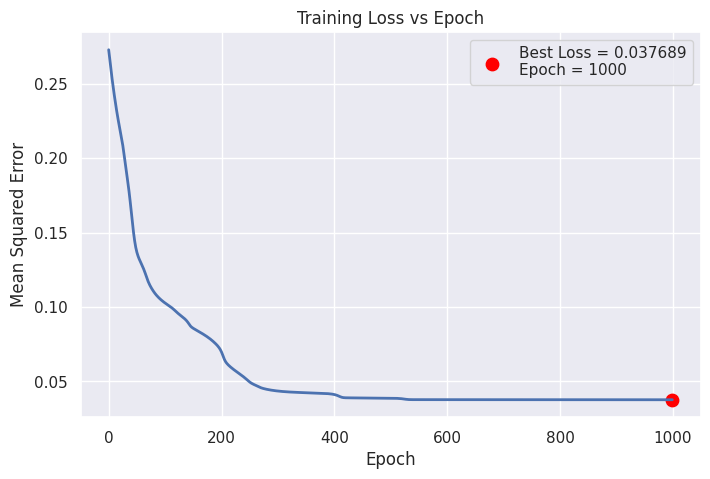

Epochs:  1000
Learning Rate:  0.015
Train Accuracy:  0.7764705882352941
Test Accuracy:  0.7906976744186046




/tmp/ipykernel_56041/4098597323.py:42: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(epochs), total=epochs, unit='epochs'):


  0%|          | 0/5000 [00:00<?, ?epochs/s]

Initial Loss : 0.224318
Final Loss   : 0.052239
Best Loss    : 0.052239
Best Epoch   : 5000


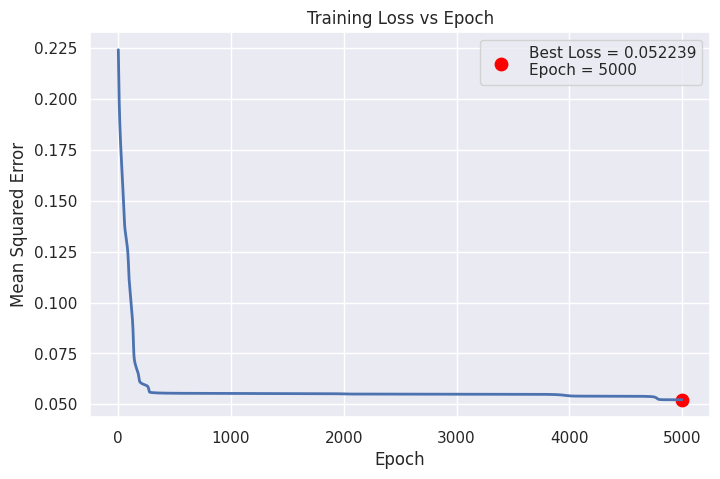

Epochs:  5000
Learning Rate:  0.015
Train Accuracy:  0.7764705882352941
Test Accuracy:  0.7558139534883721




In [35]:
epochs = [10, 1000, 1000, 5000, 1000, 5000]
learnin_rates = [0.2, 0.2, 0.01, 0.01, 0.015, 0.015]
for epoch, learning_rate in zip(epochs, learnin_rates):
  sigmoid_model.fit(X_scaled_train, Y_scaled_train, epochs=epoch, learning_rate=learning_rate, display_loss=True);
  Y_pred_train = sigmoid_model.predict(X_scaled_train)
  Y_pred_test = sigmoid_model.predict(X_scaled_test)
  Y_pred_binarised_train = sigmoid_model.binarize(Y_pred_train, scaled_threshold);
  Y_pred_binarised_test =  sigmoid_model.binarize(Y_pred_test, scaled_threshold);
  train_accuracy = sigmoid_model.accuracy(Y_pred_binarised_train, Y_binarised_train);
  test_accuracy = sigmoid_model.accuracy(Y_pred_binarised_test, Y_binarised_test);
  print("Epochs: ", epoch);
  print("Learning Rate: ", learning_rate);
  print("Train Accuracy: ", train_accuracy);
  print("Test Accuracy: ", test_accuracy);
  print("\n");